# FISHER TEST

The aim of this Jupyter Notebook is to evaluate the significant differences in the subset of neuronal cluster abundances between S. mediterranea **heads** and **body** cells using the **Fisher test**. 

# Importing modules and settings

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import math
import seaborn as sns

In [2]:
from scipy import stats
from Bio import SeqIO
from matplotlib.pyplot import rc_context

In [3]:
pd.options.display.float_format = '{:,.3f}'.format

In [4]:
pd.set_option('use_inf_as_na',True)

In [5]:
umap_cmap = sns.blend_palette(['xkcd:light grey', 'xkcd:indigo'], as_cmap = True)

In [6]:
sc.settings.verbosity = 4 
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')


scanpy==1.9.1 anndata==0.9.1 umap==0.5.3 numpy==1.21.5 scipy==1.7.3 pandas==1.4.2 scikit-learn==1.0.2 statsmodels==0.13.2 python-igraph==0.9.11 pynndescent==0.5.7


# Declaring input and output files

In [7]:
adata = sc.read_h5ad('./Serotonergic_data_annotated.h5ad')

In [8]:
adata.obs

,sample,biological_rep,technical_rep,library,sample_bio,unique,sample_rep,unique_rep,n_counts,n_genes,...,pct_counts_mt,leiden_1,leiden_2,leiden_3,leiden_4,ingest_names,transferred,leiden_3_names_collapsed,leiden_3_names,broad_names
L43_1_AACCATTGGAGACTAGTAACGCTCGA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,148.000,130,...,0.000,8,9,7,25,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,parenchymal
L43_1_CATTCGACGGAGATCGCACGCTGATC,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,176.000,159,...,0.000,1,1,1,0,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,neurons
L43_1_ACGGAGGCGGTGGAACAATAGGATGA,gfp(RNAi),B2,T1,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib1,502.000,359,...,0.000,0,0,0,7,neoblasts 1,neoblasts 1,neoblasts,neoblasts 1,neoblasts
L43_1_GACCTTGATAACGCTCGACAAGACTA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,185.000,149,...,0.000,4,3,9,5,early epidermal progenitors,early epidermal progenitors,early epidermal progenitors 1,early epidermal progenitors 1,epidermal
L43_1_TTACCTCGACTGGAACAAAGATCGCA,lhx1/5-1(RNAi),B1,T2,Lib1,lhx1/5-1(RNAi)_B1,lhx1/5-1(RNAi)_Lib1,lhx1/5-1(RNAi)_B1_T2,lhx1/5-1(RNAi)_B1_T2_Lib1,180.000,166,...,0.000,2,6,3,9,intestinal and DV muscle,intestinal and DV muscle,intestinal and DV muscle,intestinal and DV muscle,muscle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L43_5_TAACTGGTTAAAGGTACAGAGTTAGC,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,411.000,212,...,0.000,7,37,26,49,epidermis,epidermis,epidermis 2,epidermis 2,epidermal
L43_5_GGTACCGGCAGAATCTGATGAAGAGA,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,262.000,186,...,0.000,0,0,5,4,neoblasts 1,neoblasts 1,neoblasts,neoblasts 3,neoblasts
L43_5_GCCGCAACGACCAGTTCAAGCAGGAA,gfp(RNAi),B1,T2,Lib5,gfp(RNAi)_B1,gfp(RNAi)_Lib5,gfp(RNAi)_B1_T2,gfp(RNAi)_B1_T2_Lib5,110.000,103,...,0.000,5,8,6,3,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,parenchymal
L43_5_CCAGTTCCAATGGAACAAATTGGCTC,gfp(RNAi),B2,T1,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib5,238.000,201,...,0.000,1,1,1,0,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,neurons


# Fisher test as a function

Defining variables:

In [9]:
clusteringlayer = 'leiden_3_names_collapsed'

In [10]:
samples_name = 'sample'

In [11]:
adata.obs[samples_name].cat.categories

Index(['gfp(RNAi)', 'lhx1/5-1(RNAi)', 'pitx(RNAi)'], dtype='object')

In [12]:
s1 = 'gfp(RNAi)'
s2 = 'pitx(RNAi)'

In [13]:
# Significance:
sig = 0.01

In [14]:
# Odd ratio:
ot = 0.25

Defining function:

In [15]:
def FisherTest (adata_in_use, clusteringlayer, samples_name, s1, s2):
    
    # Obtaining counts:
    
    cell_numbers = adata_in_use.obs[[samples_name, clusteringlayer]].groupby(samples_name)                 # Group data by samples and clusters.  
    cellcounts = {}                                                                                        # Create an empty diccionary
    for i in adata_in_use.obs[samples_name].cat.categories:                                                # For every sample (i)
        cellcounts[i] = cell_numbers.get_group(i)[clusteringlayer].value_counts().rename(i).sort_index()   # Obtain the counts per cluster
    counts_df = pd.DataFrame.from_dict(cellcounts)                                                         # Create a dataframe of counts from diccionary (cellcounts)
    
    oddsdict ={}     # Create empty dictionary for odd values
    pvalsdict = {}   # Create empty dictionary for p-values

    for j in adata_in_use.obs[clusteringlayer].cat.categories:                          # For each cluster(j)
        cl_counts = counts_df.loc[j,[s1, s2]].to_list()                                 # Obtain the counts per cluster in each sample 
        ncl_counts = (counts_df[[s1, s2]].sum() - counts_df.loc[j,[s1, s2]]).to_list()  # For each sample: total counts - counts per cluster
        oddsratio, pvalue = stats.fisher_exact([cl_counts, ncl_counts])                 # Run a fisher test to obtain the odd and p-values
        oddsdict[j] = oddsratio                                                         # Add odd ratio values to a dictionary
        pvalsdict[j] = pvalue                                                           # Add p values to a dictionary
        
    counts_dict = {}   # Create empty dictionary

    percs_df = counts_df[[s2, s1]] / counts_df[[s2, s1]].sum(axis = 0) * 100  # Calculate counts as percentage (counts per cluster / total counts * 100)
    percs_diff = percs_df[s2]-percs_df[s1]                                    # Substration of percentages between samples (creates column value % diff)
    
    fisher_test = pd.concat([pd.Series(pvalsdict),pd.Series(oddsdict), percs_diff], axis = 1, keys = ['pvals', 'odds', '% diff']) # Create a DataFrame with three columns: pval, odds and % diff    
    
    return fisher_test, counts_df, percs_df 

# Fisher test

In [16]:
adata_in_use = adata

Running Fisher test:

In [17]:
fisher_test, counts_df, percs_df = FisherTest(adata_in_use, clusteringlayer, samples_name, s1, s2)

In [18]:
counts_df.head()

,gfp(RNAi),lhx1/5-1(RNAi),pitx(RNAi)
neoblasts,3165,2542,2708
chat+ neurons 1,1132,1154,1049
body wall muscle,775,819,816
intestinal and DV muscle,875,766,763
phagocyte progenitors,899,696,789


In [19]:
fisher_test

,pvals,odds,% diff
neoblasts,0.005,1.086,-1.227
chat+ neurons 1,0.773,0.986,0.086
body wall muscle,0.004,0.863,0.698
intestinal and DV muscle,0.322,1.052,-0.246
phagocyte progenitors,0.381,1.045,-0.219
pgrn+ parenchymal cells 2,0.106,0.913,0.367
pgrn+ parenchymal cells 1,0.000,0.755,1.102
late epidermal progenitors,0.182,1.084,-0.285
early epidermal progenitors 1,0.011,0.859,0.537
phagocytes,0.058,1.125,-0.392


Obtainin **UP and DOWN** regulated clusters:

In [20]:
# All significant clusters:
fisher_test_sig = fisher_test[fisher_test['pvals'] < sig].index.to_list()

In [21]:
# Clusters significantly UP and DOWN regulated:
down = (fisher_test['pvals'] < sig) & (np.log2(fisher_test['odds']) > ot)
up = (fisher_test['pvals'] < sig) & (np.log2(fisher_test['odds']) < -ot)

In [22]:
fisher_test[down]

,pvals,odds,% diff
epidermis 1,0.000,1.324,-0.729
germ cell progenitors,0.000,1.698,-0.500
tph+ neurons,0.000,2.662,-0.324


In [23]:
fisher_test[up]

,pvals,odds,% diff
pgrn+ parenchymal cells 1,0.000,0.755,1.102
psap+ parenchymal cells,0.003,0.747,0.371


Saving progress:

In [24]:
excel_writer = pd.ExcelWriter('./outputs/fisher_test/Smed_sero_pitx_counts.xlsx', engine='xlsxwriter')

In [25]:
counts_df.to_excel(excel_writer, sheet_name = 'counts', index=True)
percs_df.to_excel(excel_writer, sheet_name = 'percentages', index=True)

In [26]:
excel_writer.save()

In [27]:
excel_writer = pd.ExcelWriter('./outputs/fisher_test/Smed_sero_pitx_fisher_test.xlsx', engine='xlsxwriter')

In [28]:
fisher_test.to_excel(excel_writer, sheet_name = 'fisher_test', index=True)
fisher_test[up].to_excel(excel_writer, sheet_name = 'UP in pitx', index=True)
fisher_test[down].to_excel(excel_writer, sheet_name = 'DOWN in pitx', index=True)

In [29]:
excel_writer.save()

# Plotting results

Loading final results from Fisher test

In [30]:
counts_adata = pd.read_excel('./outputs/fisher_test/Smed_sero_pitx_counts.xlsx', index_col = 0)

In [31]:
fisher_adata = pd.read_excel('./outputs/fisher_test/Smed_sero_pitx_fisher_test.xlsx', sheet_name = 'fisher_test', index_col = 0)

In [32]:
adata_down = pd.read_excel('./outputs/fisher_test/Smed_sero_pitx_fisher_test.xlsx', sheet_name = 'DOWN in pitx', index_col=0)
adata_up = pd.read_excel('./outputs/fisher_test/Smed_sero_pitx_fisher_test.xlsx', sheet_name = 'UP in pitx', index_col=0)

C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:369: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:379: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


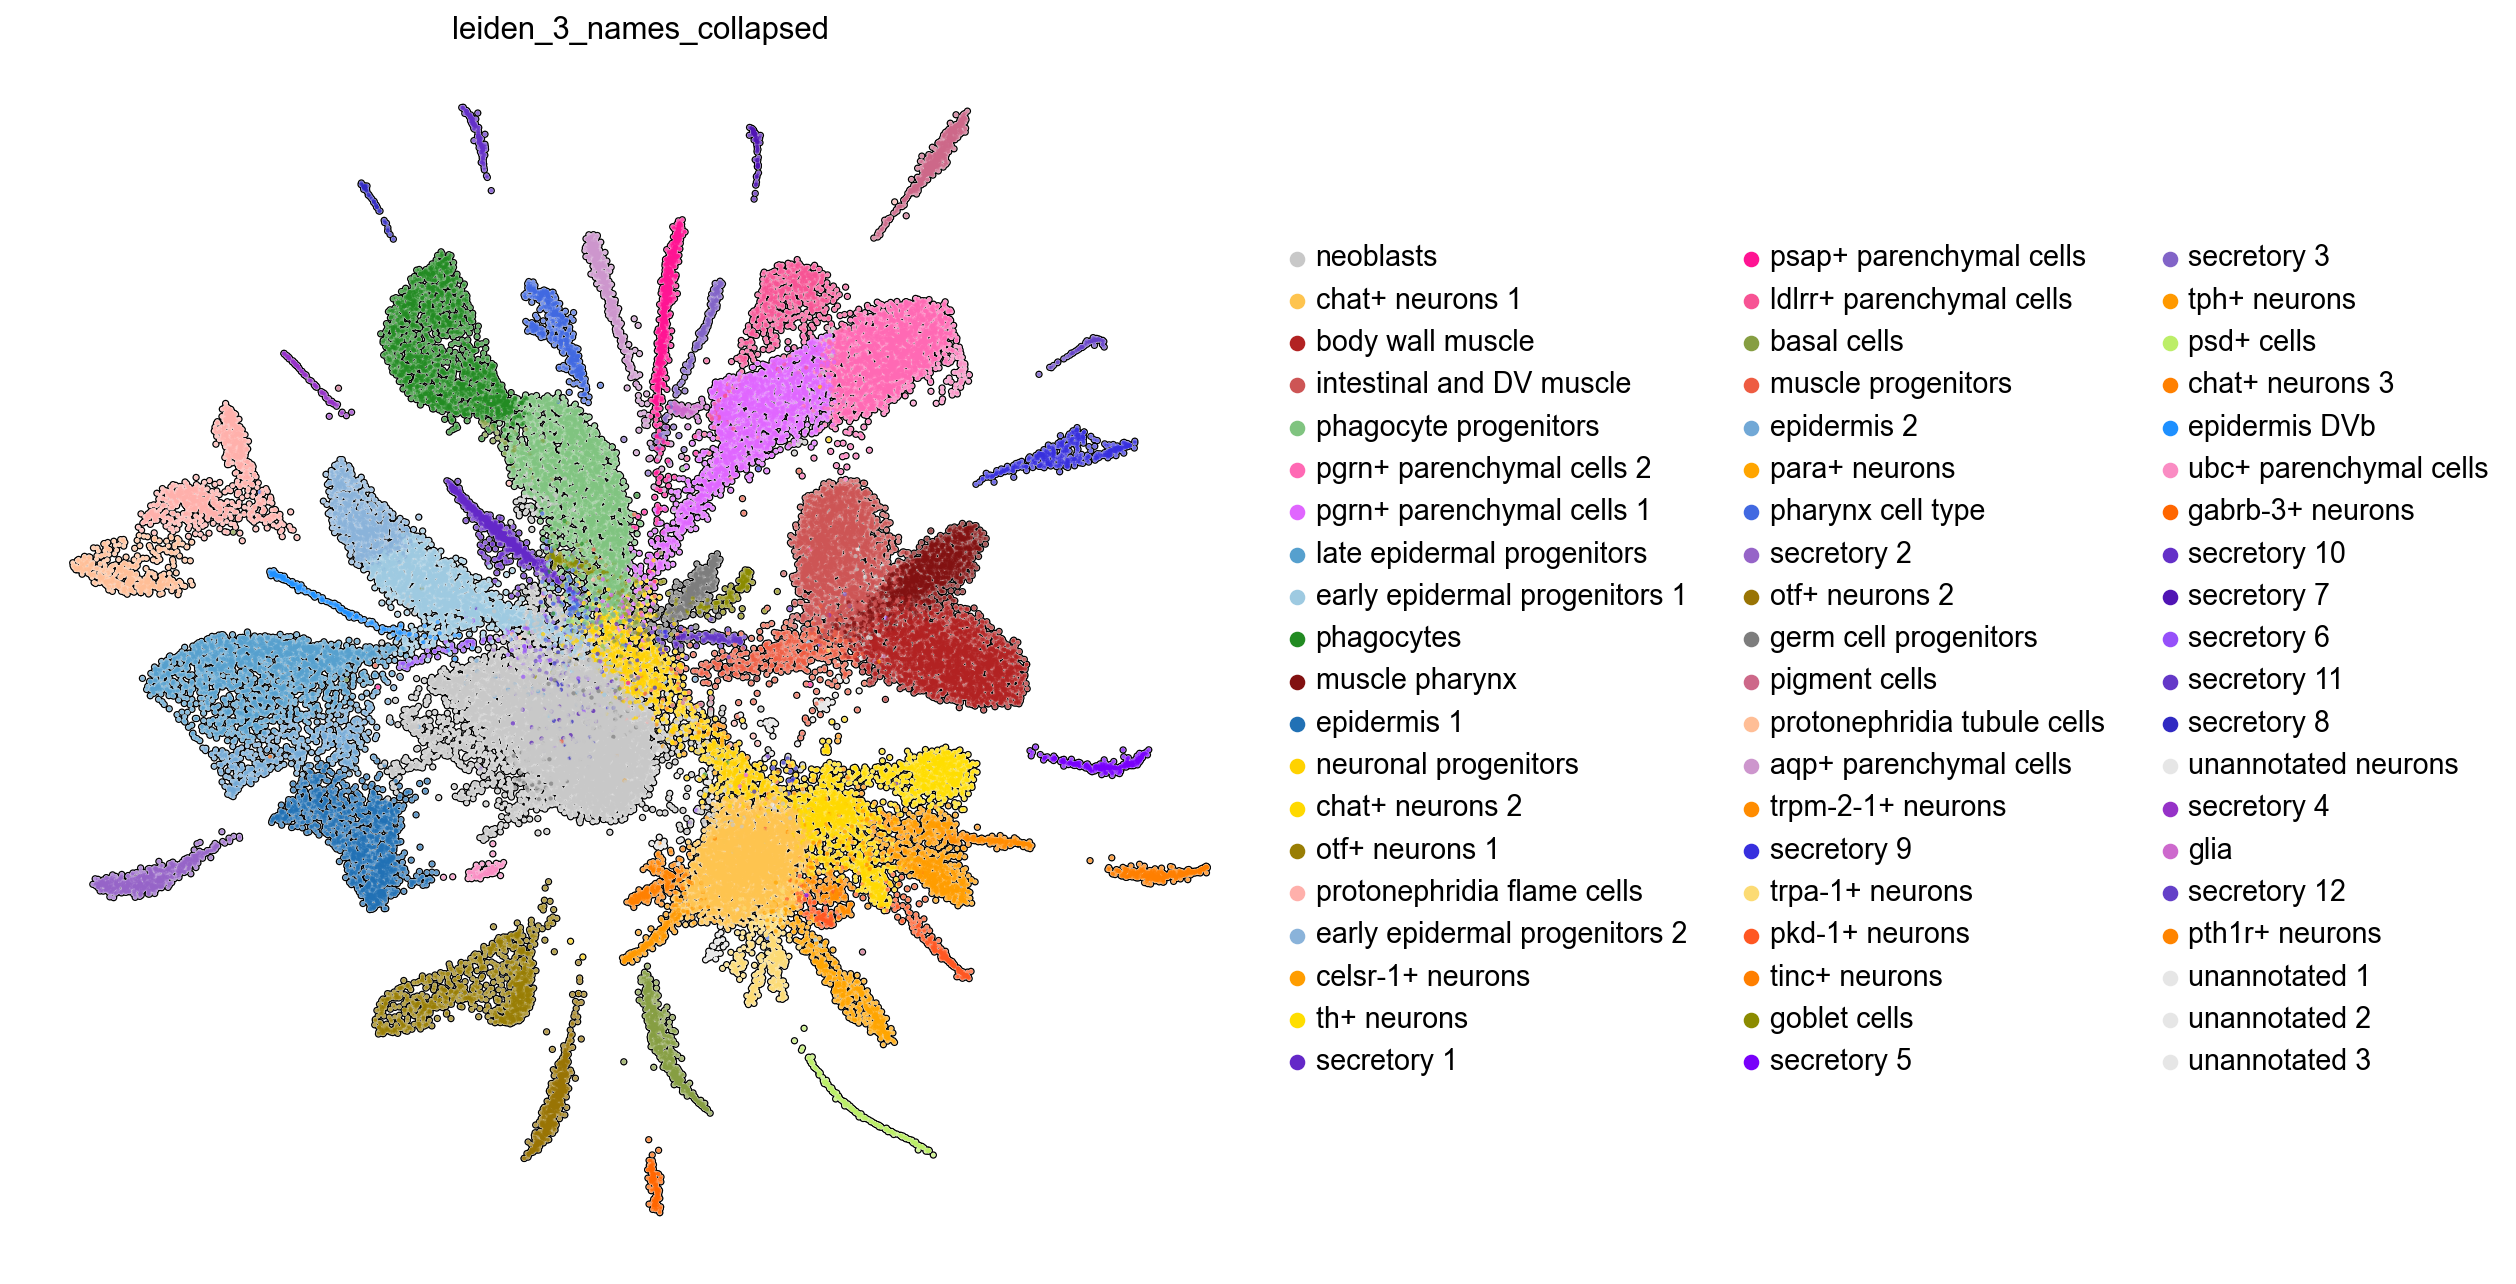

In [33]:
with rc_context({'figure.figsize': (10, 10)}):
    sc.pl.umap(adata, color=clusteringlayer , size = 15, frameon=False, add_outline = True)

In [34]:
sample_palette = ['#A36B2B', '#E64F72', '#2787A0']

C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:369: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:379: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


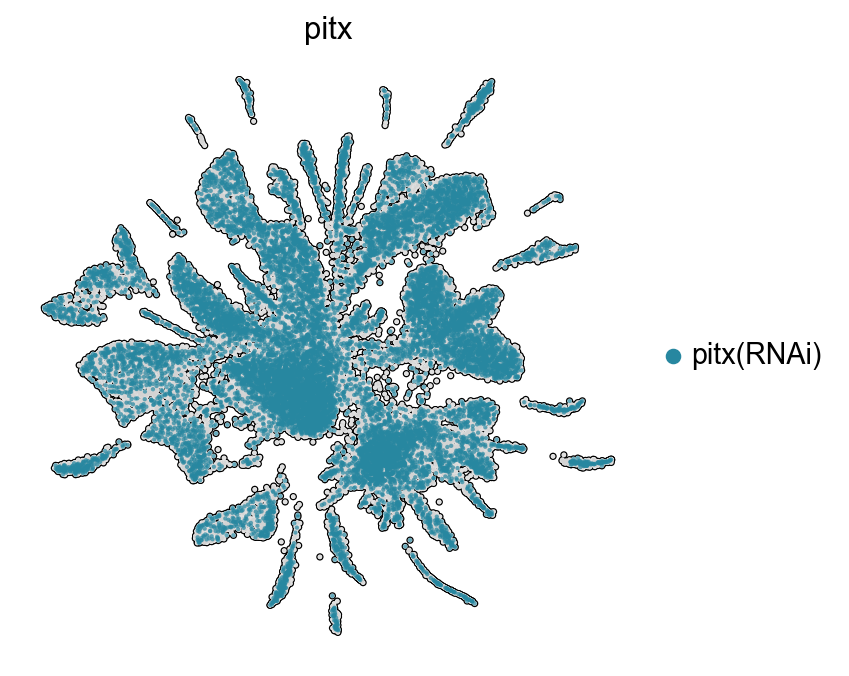

C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:369: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:379: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


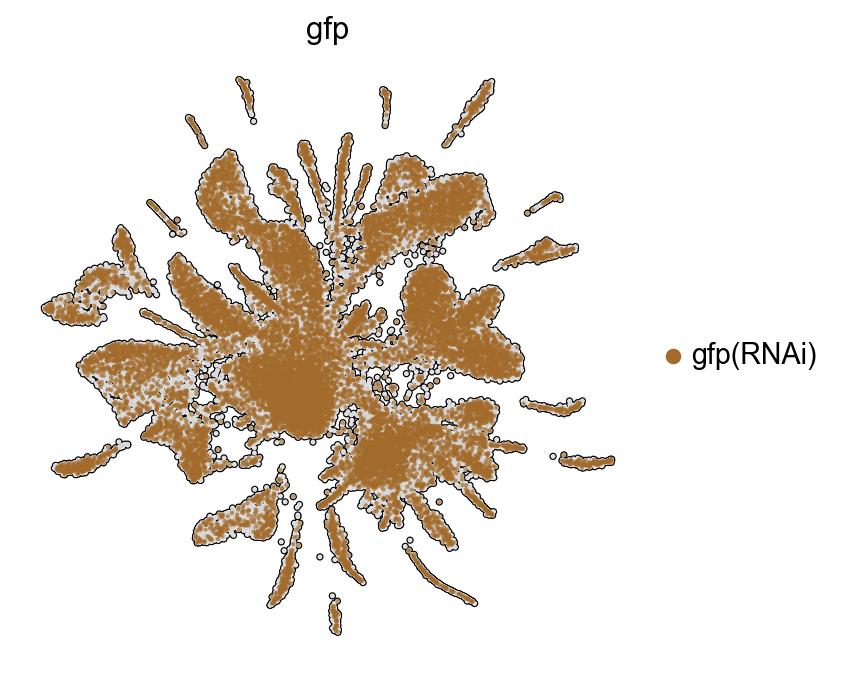

In [35]:
with rc_context({'figure.figsize': (5, 5)}):
    sc.pl.umap(adata, color='sample', palette = sample_palette,  groups= 'pitx(RNAi)', title='pitx', size = 15, frameon=False, add_outline = True, na_in_legend = False, save= '_adata_pitx.pdf')
    sc.pl.umap(adata, color='sample', palette = sample_palette, groups='gfp(RNAi)', title='gfp', size = 15, frameon=False, add_outline = True, na_in_legend = False, save= '_adata_gfp.pdf')

Defining variables:

In [36]:
adata_in_use = adata

In [37]:
significants = fisher_adata[fisher_adata['pvals'] < sig].index.to_list()

In [38]:
significants

['neoblasts',
 'body wall muscle',
 'pgrn+ parenchymal cells 1',
 'epidermis 1',
 'psap+ parenchymal cells',
 'germ cell progenitors',
 'tph+ neurons']

In [39]:
ft = fisher_adata

In [40]:
down = adata_down.index.tolist()
up = adata_up.index.tolist()

In [41]:
down

['epidermis 1', 'germ cell progenitors', 'tph+ neurons']

In [42]:
up

['pgrn+ parenchymal cells 1', 'psap+ parenchymal cells']

In [43]:
ctrl = 'gfp'
test = 'pitx'

### UMAP plots for (all significants, up and down)

C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)


C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


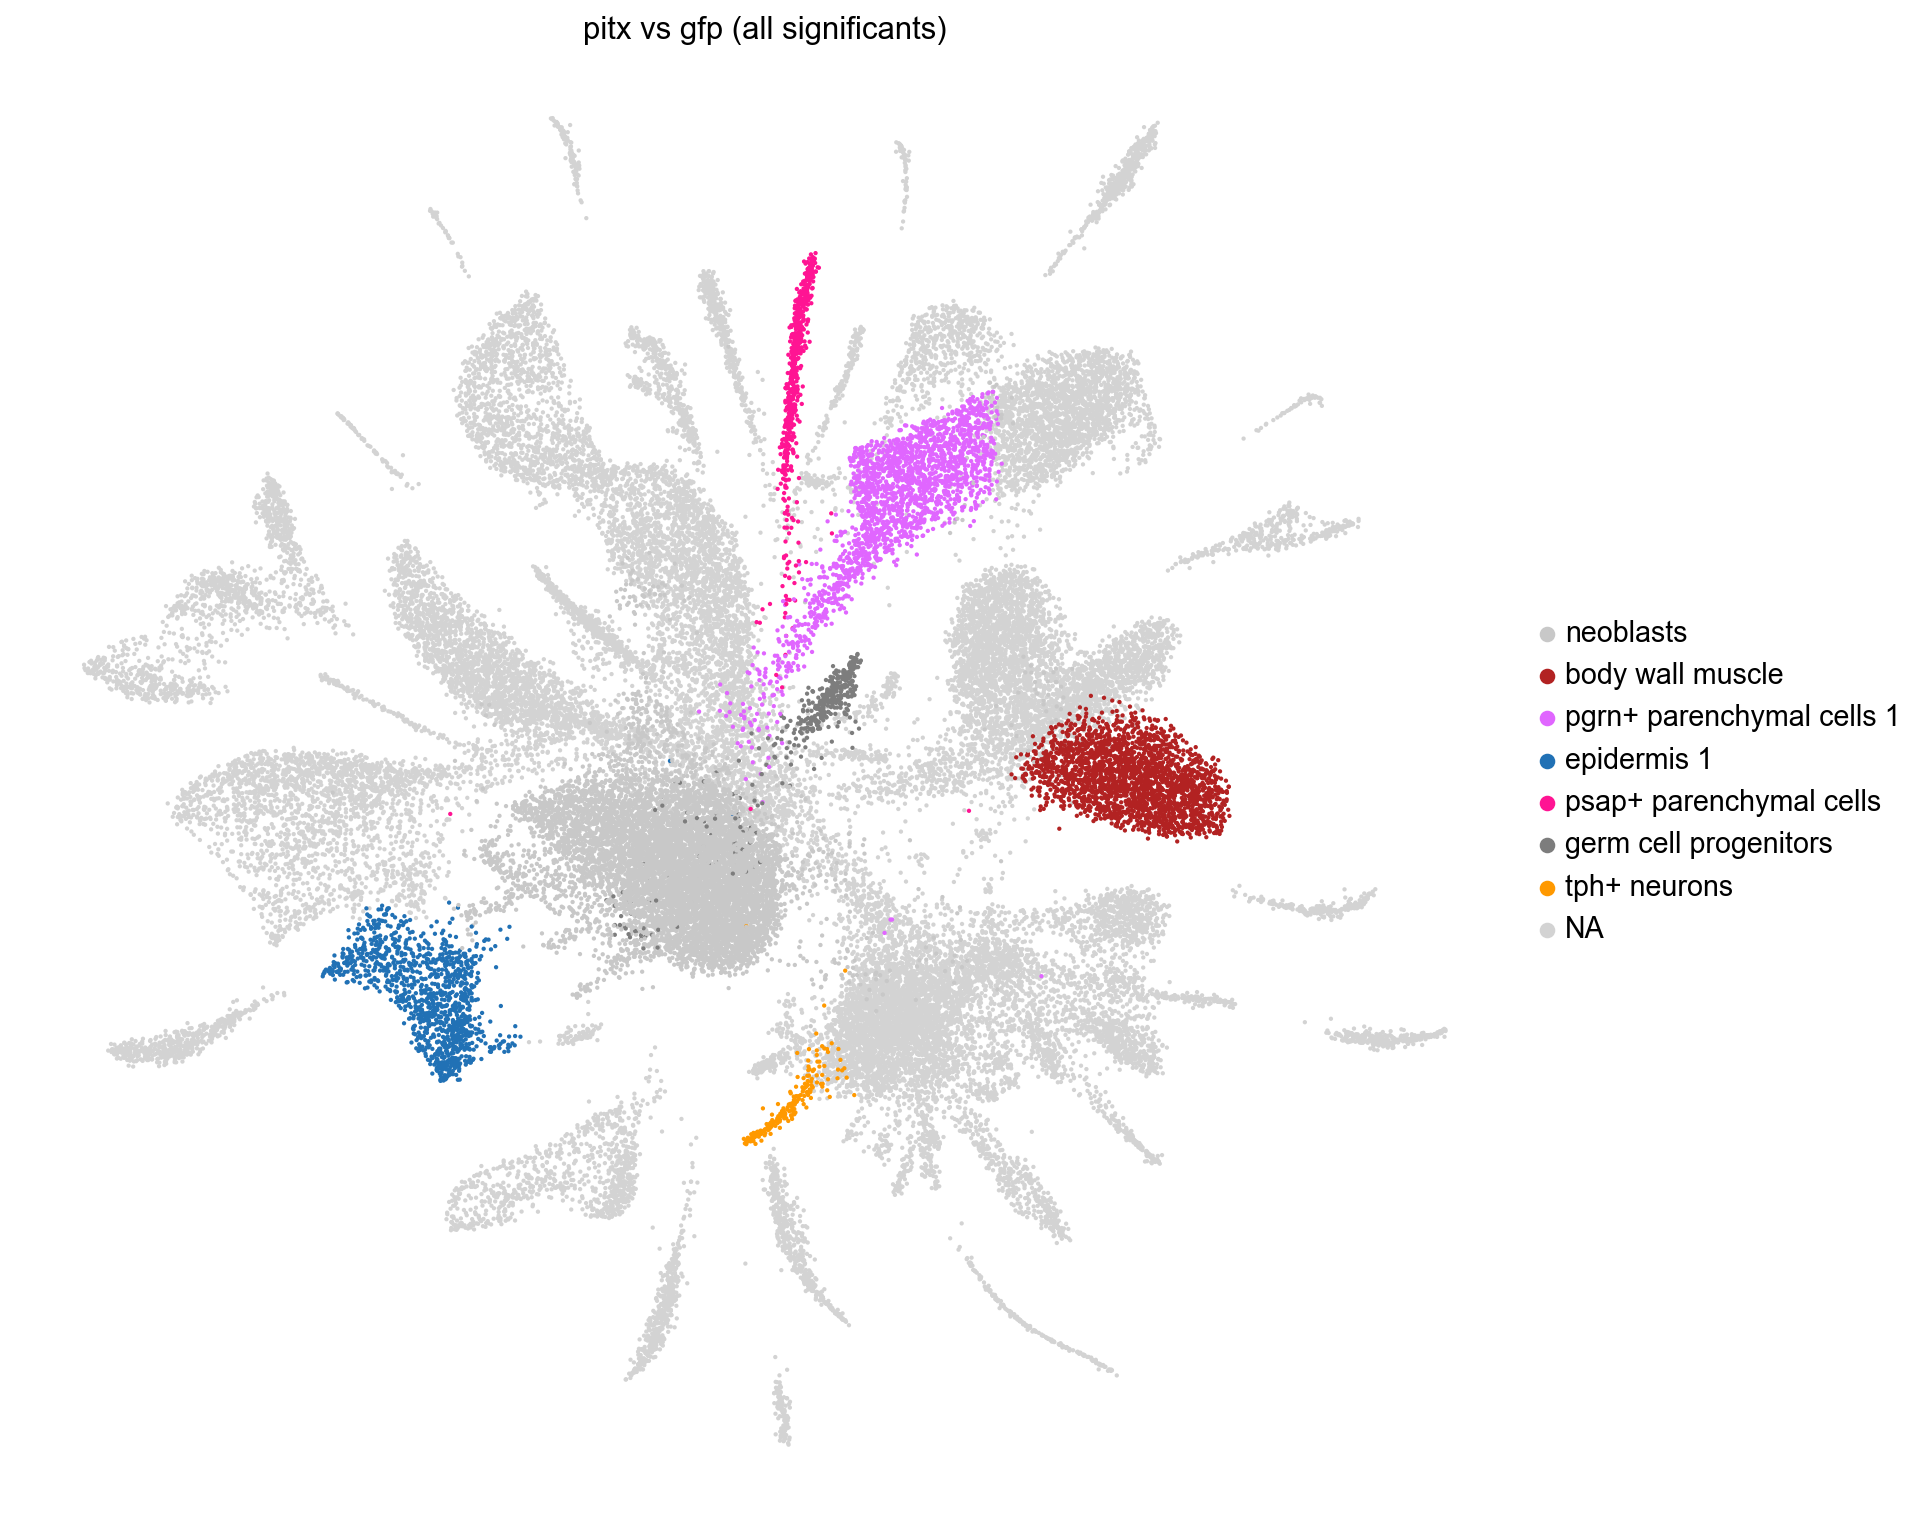

C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)


C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


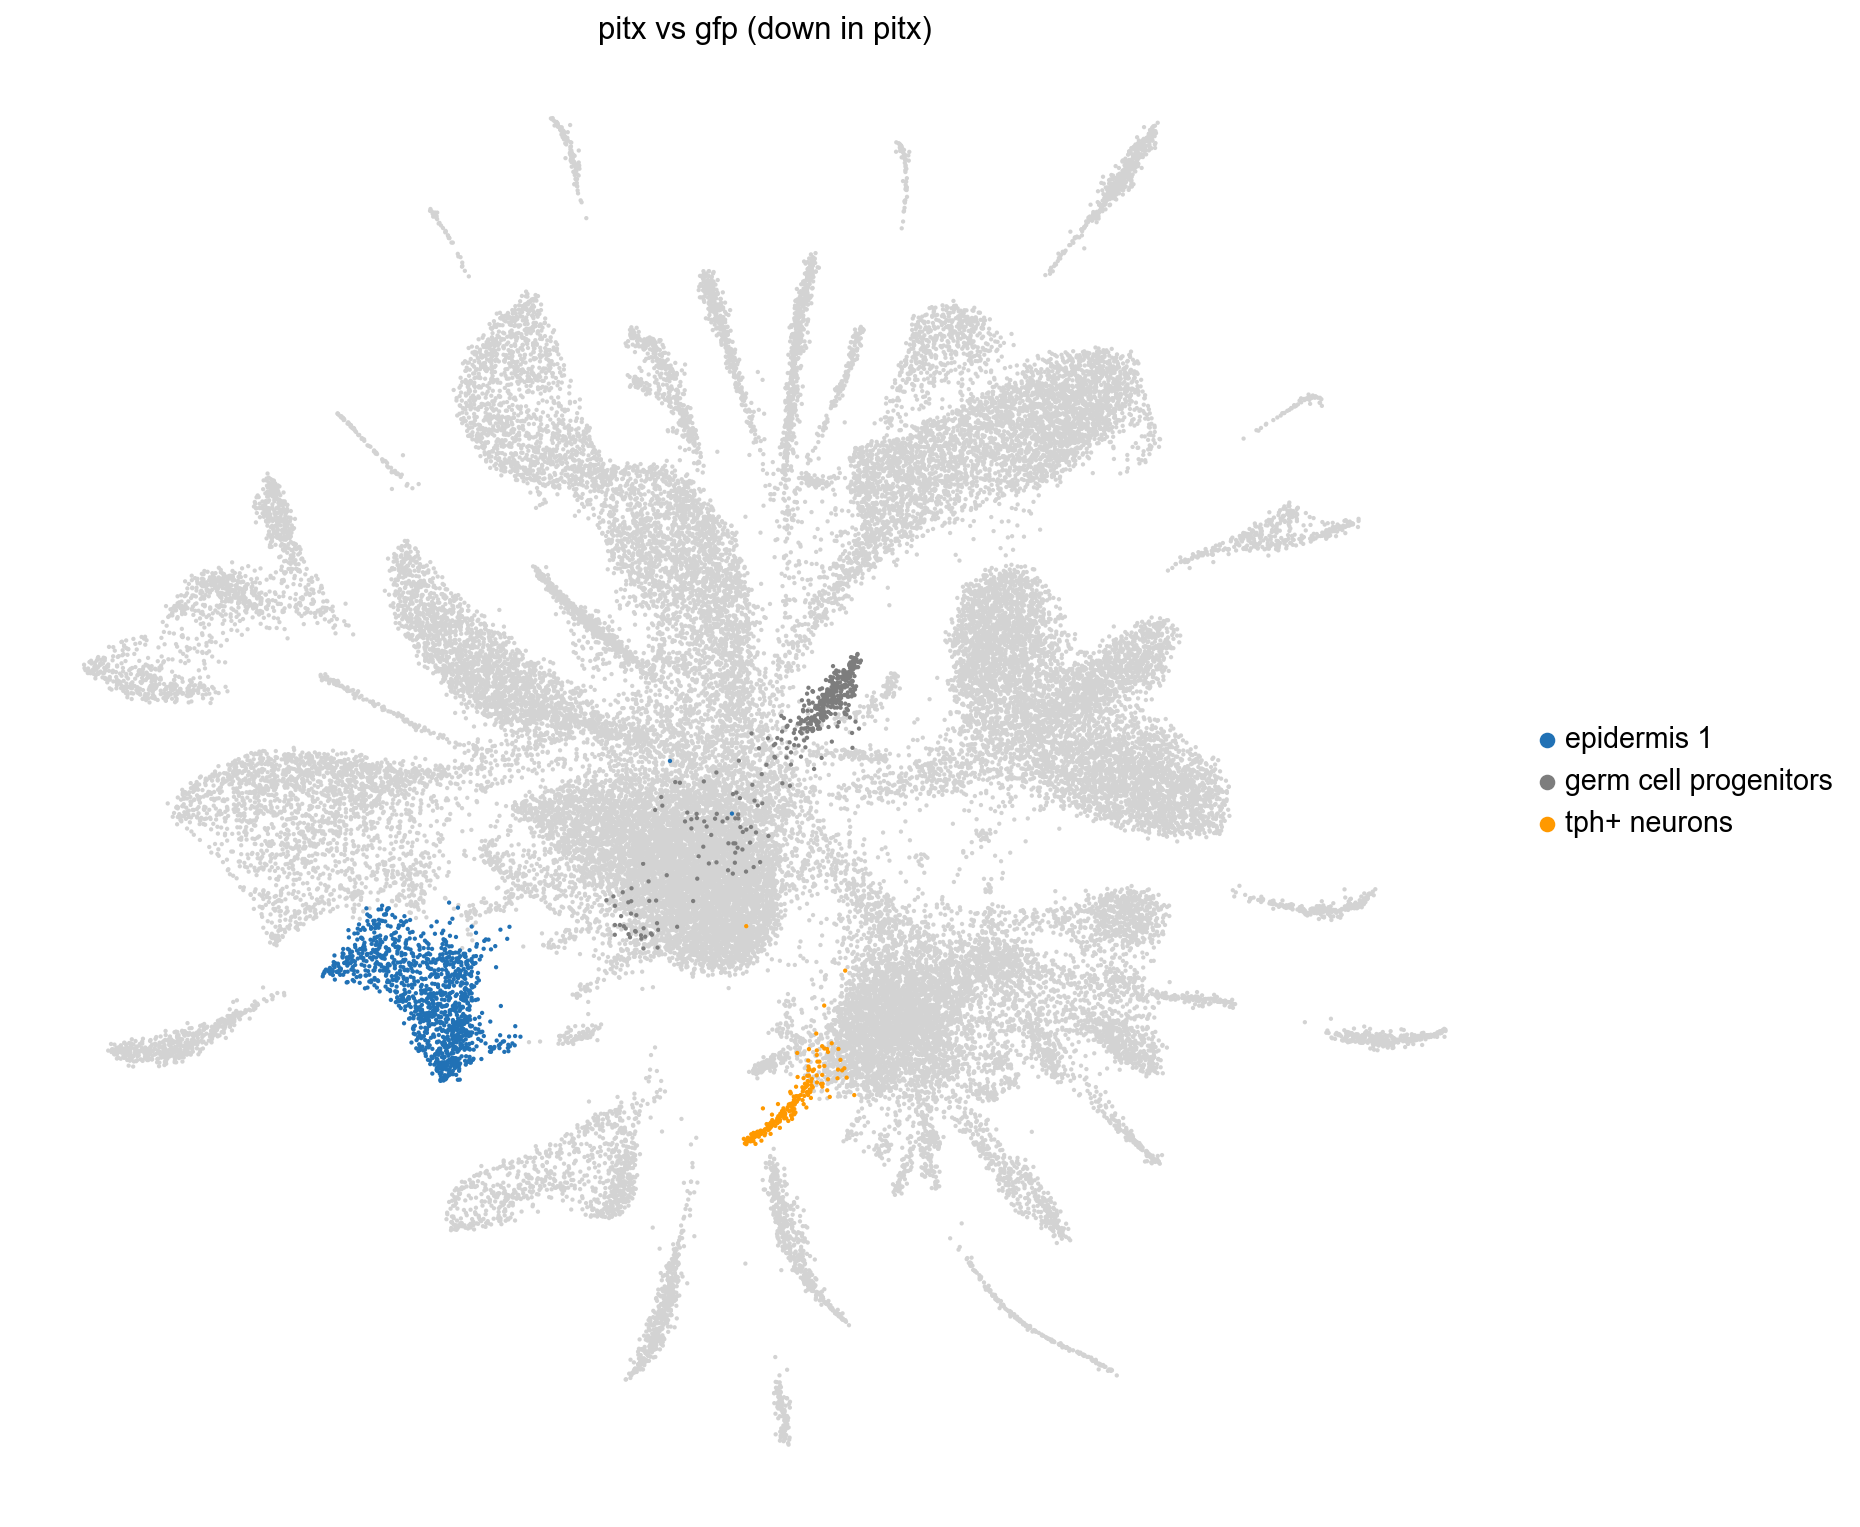

C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)


C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


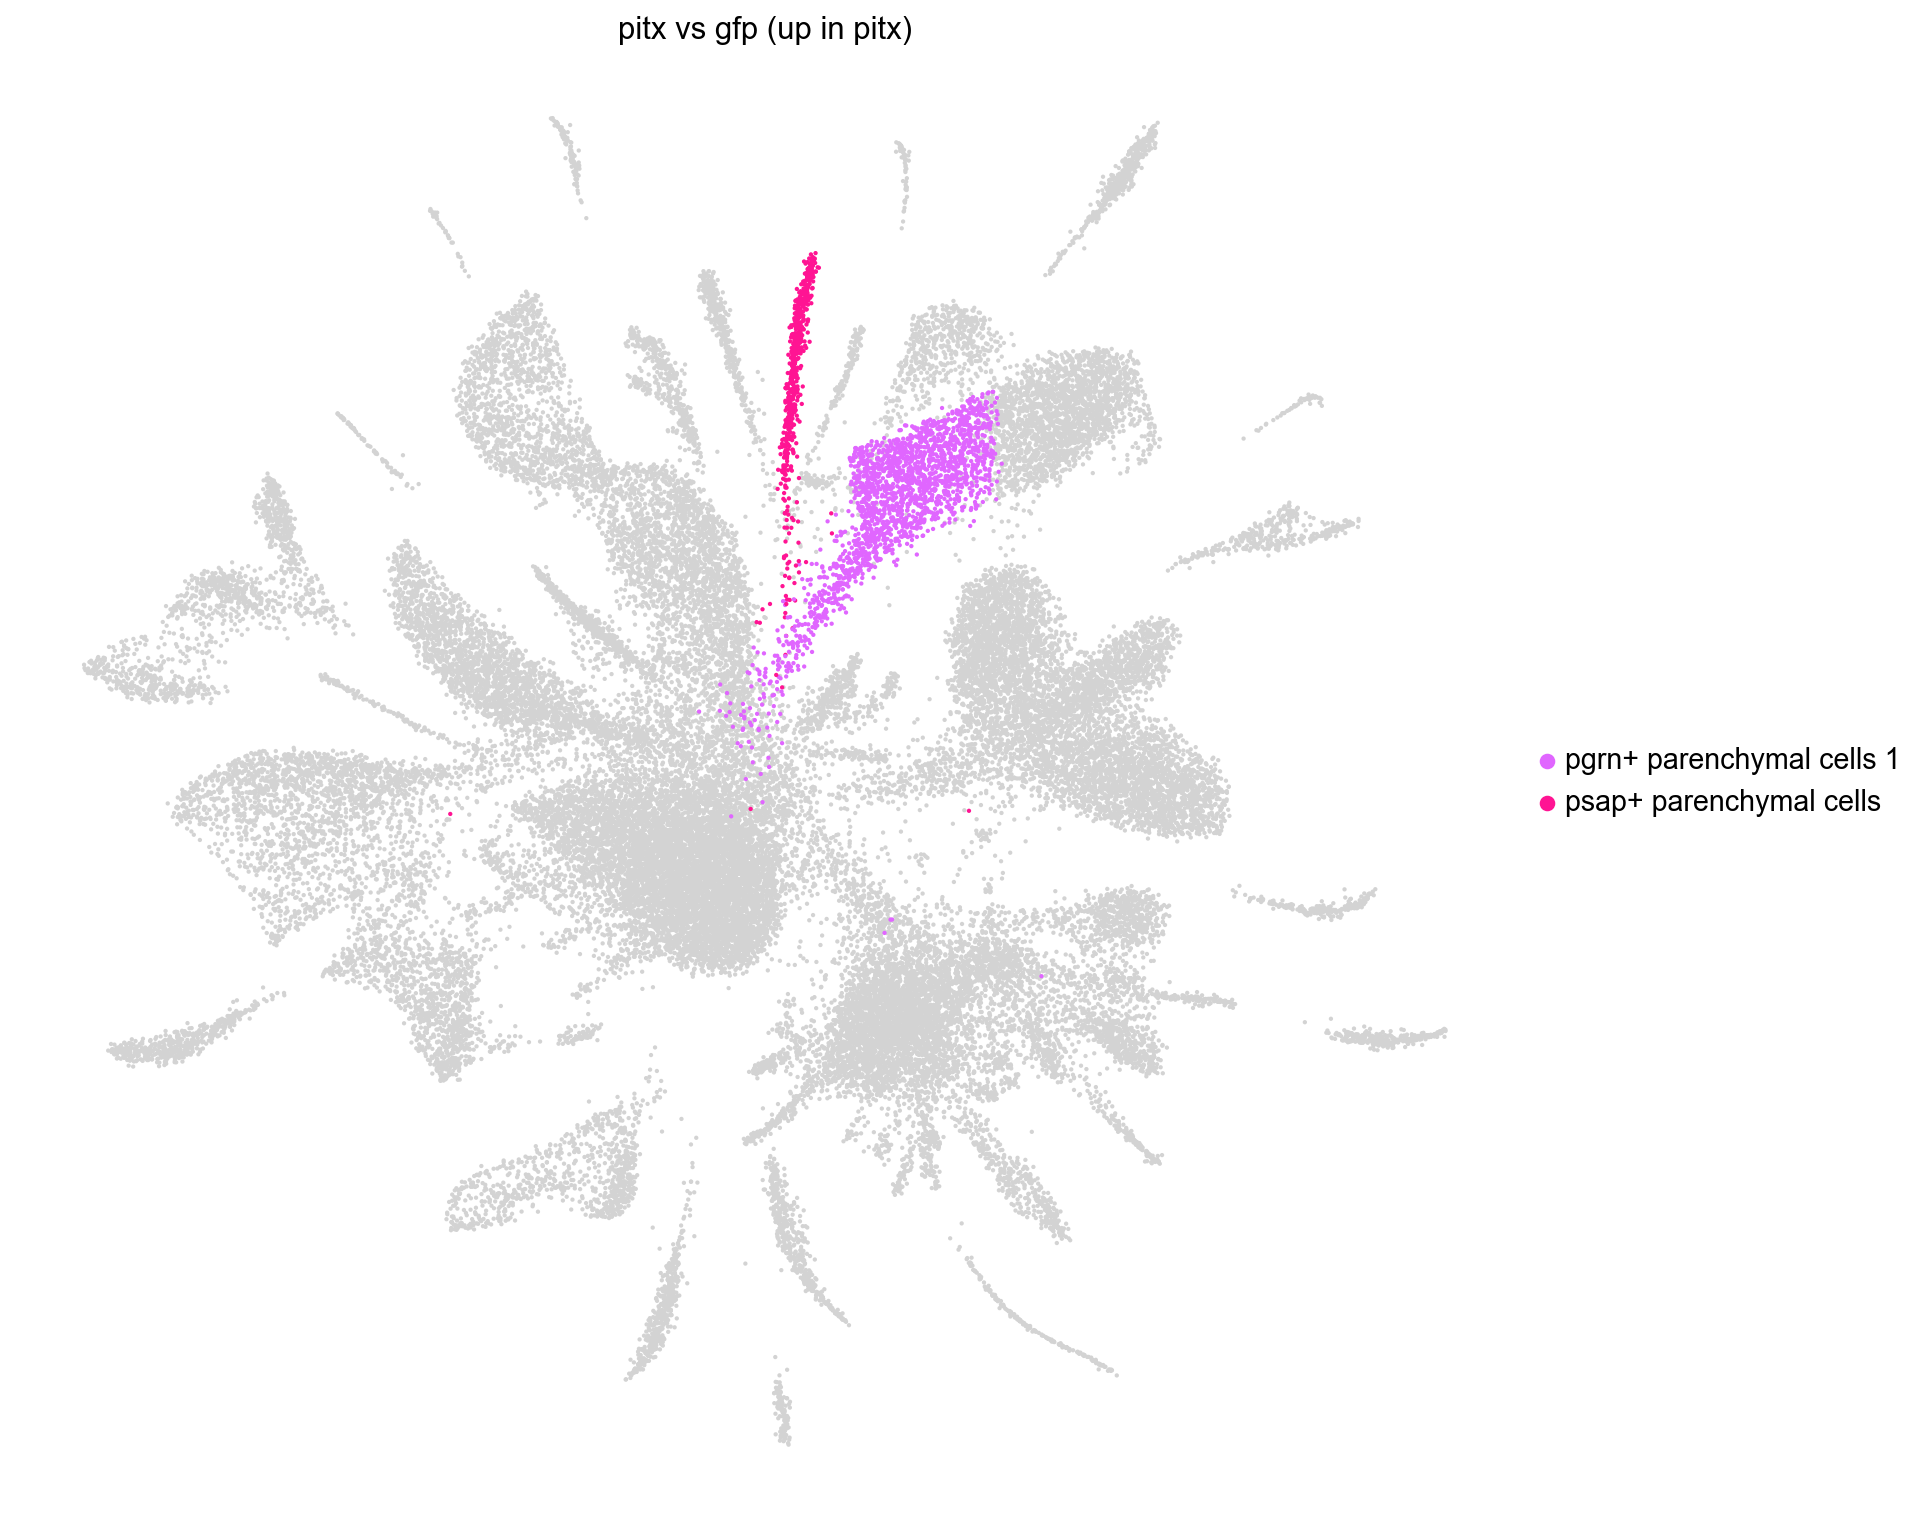

In [44]:
with plt.rc_context({'figure.figsize': (12, 12)}):
    sc.pl.umap(adata_in_use, color=clusteringlayer, legend_loc='right margin', legend_fontoutline = 5, title= test + ' vs ' + ctrl + ' (all significants)', size = 15, groups = significants, frameon=False, add_outline = False, save= '_adata_all_significants.pdf')
    sc.pl.umap(adata_in_use, color=clusteringlayer, legend_loc='right margin', legend_fontoutline = 5, title= test + ' vs ' + ctrl + ' (down in pitx)', size = 15, groups = down, na_in_legend=False, frameon=False, add_outline = False, save= '_adata_down.pdf')
    sc.pl.umap(adata_in_use, color=clusteringlayer, legend_loc='right margin', legend_fontoutline = 5, title= test + ' vs ' + ctrl + ' (up in pitx)', size = 15, groups = up, na_in_legend=False, frameon=False, add_outline = False, save= '_adata_up.pdf')

### Volcano plot:

C:\Users\19125778\Anaconda3\lib\site-packages\pandas\core\internals\blocks.py:402: RuntimeWarning: invalid value encountered in log2
  result = func(self.values, **kwargs)
C:\Users\19125778\AppData\Local\Temp\ipykernel_14196\3478966499.py:24: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


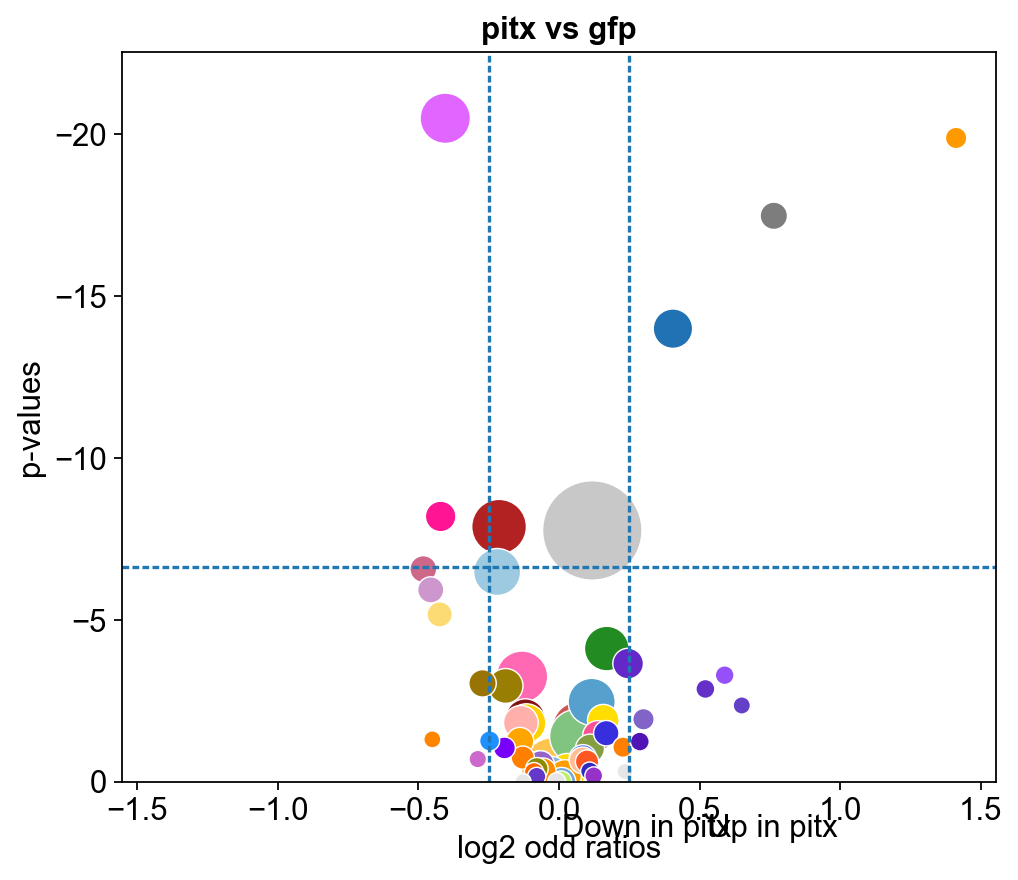

In [45]:
max_y = abs(np.log2(ft['pvals'])).max() * 1.10          # Size limit of the y axis = maximum absolute value in column 'pvals' multiplied by a factor
max_x= abs(np.log2(ft['odds']).dropna()).max() * 1.10   # Size limit of the x axis = maximum absolute value in column 'odds' multiplied by a factor
fig, axs = plt.subplots(figsize = (7, 6))
sns.scatterplot(data = np.log2(ft), x = 'odds', y = 'pvals',
    size = adata_in_use.obs[clusteringlayer].value_counts(),
    sizes=(50, 2000),
    hue = ft.index,
    palette = list(adata_in_use.uns[clusteringlayer+'_colors']),
    legend = False,
    ax = axs)
axs.axhline(y=np.log2(sig), xmin=0, xmax=1, dashes = (2,1))
axs.axvline(x= ot, ymin=0, ymax=1, dashes = (2,1))
axs.axvline(x= -ot, ymin=0, ymax=1, dashes = (2,1))
axs.invert_yaxis()
axs.set_title(test + ' vs ' + ctrl, weight='bold')
axs.set_xlim(-(max_x), max_x)
axs.set_ylim(0,-(max_y))
axs.yaxis.set_visible(True)
axs.set_xlabel('log2 odd ratios')
axs.set_ylabel('p-values')
axs.text(.01, .99, 'Down in '+ test, ha='left', va='top')
axs.text(.99, .99, 'Up in '+ test, ha='right', va='top')
axs.grid(False)
fig.show()
fig.savefig('./outputs/fisher_test/volcano_adata2.pdf')

### Histogram:

Defining plot axes:

In [46]:
log2_odds = pd.DataFrame(np.log2(ft['odds']))

In [47]:
Y_axis = log2_odds['odds'] # Plot Y-axis

In [48]:
index = log2_odds['odds'].index # Plot X-axis

In [49]:
x_pos = index # X-axis length

Creating plot:

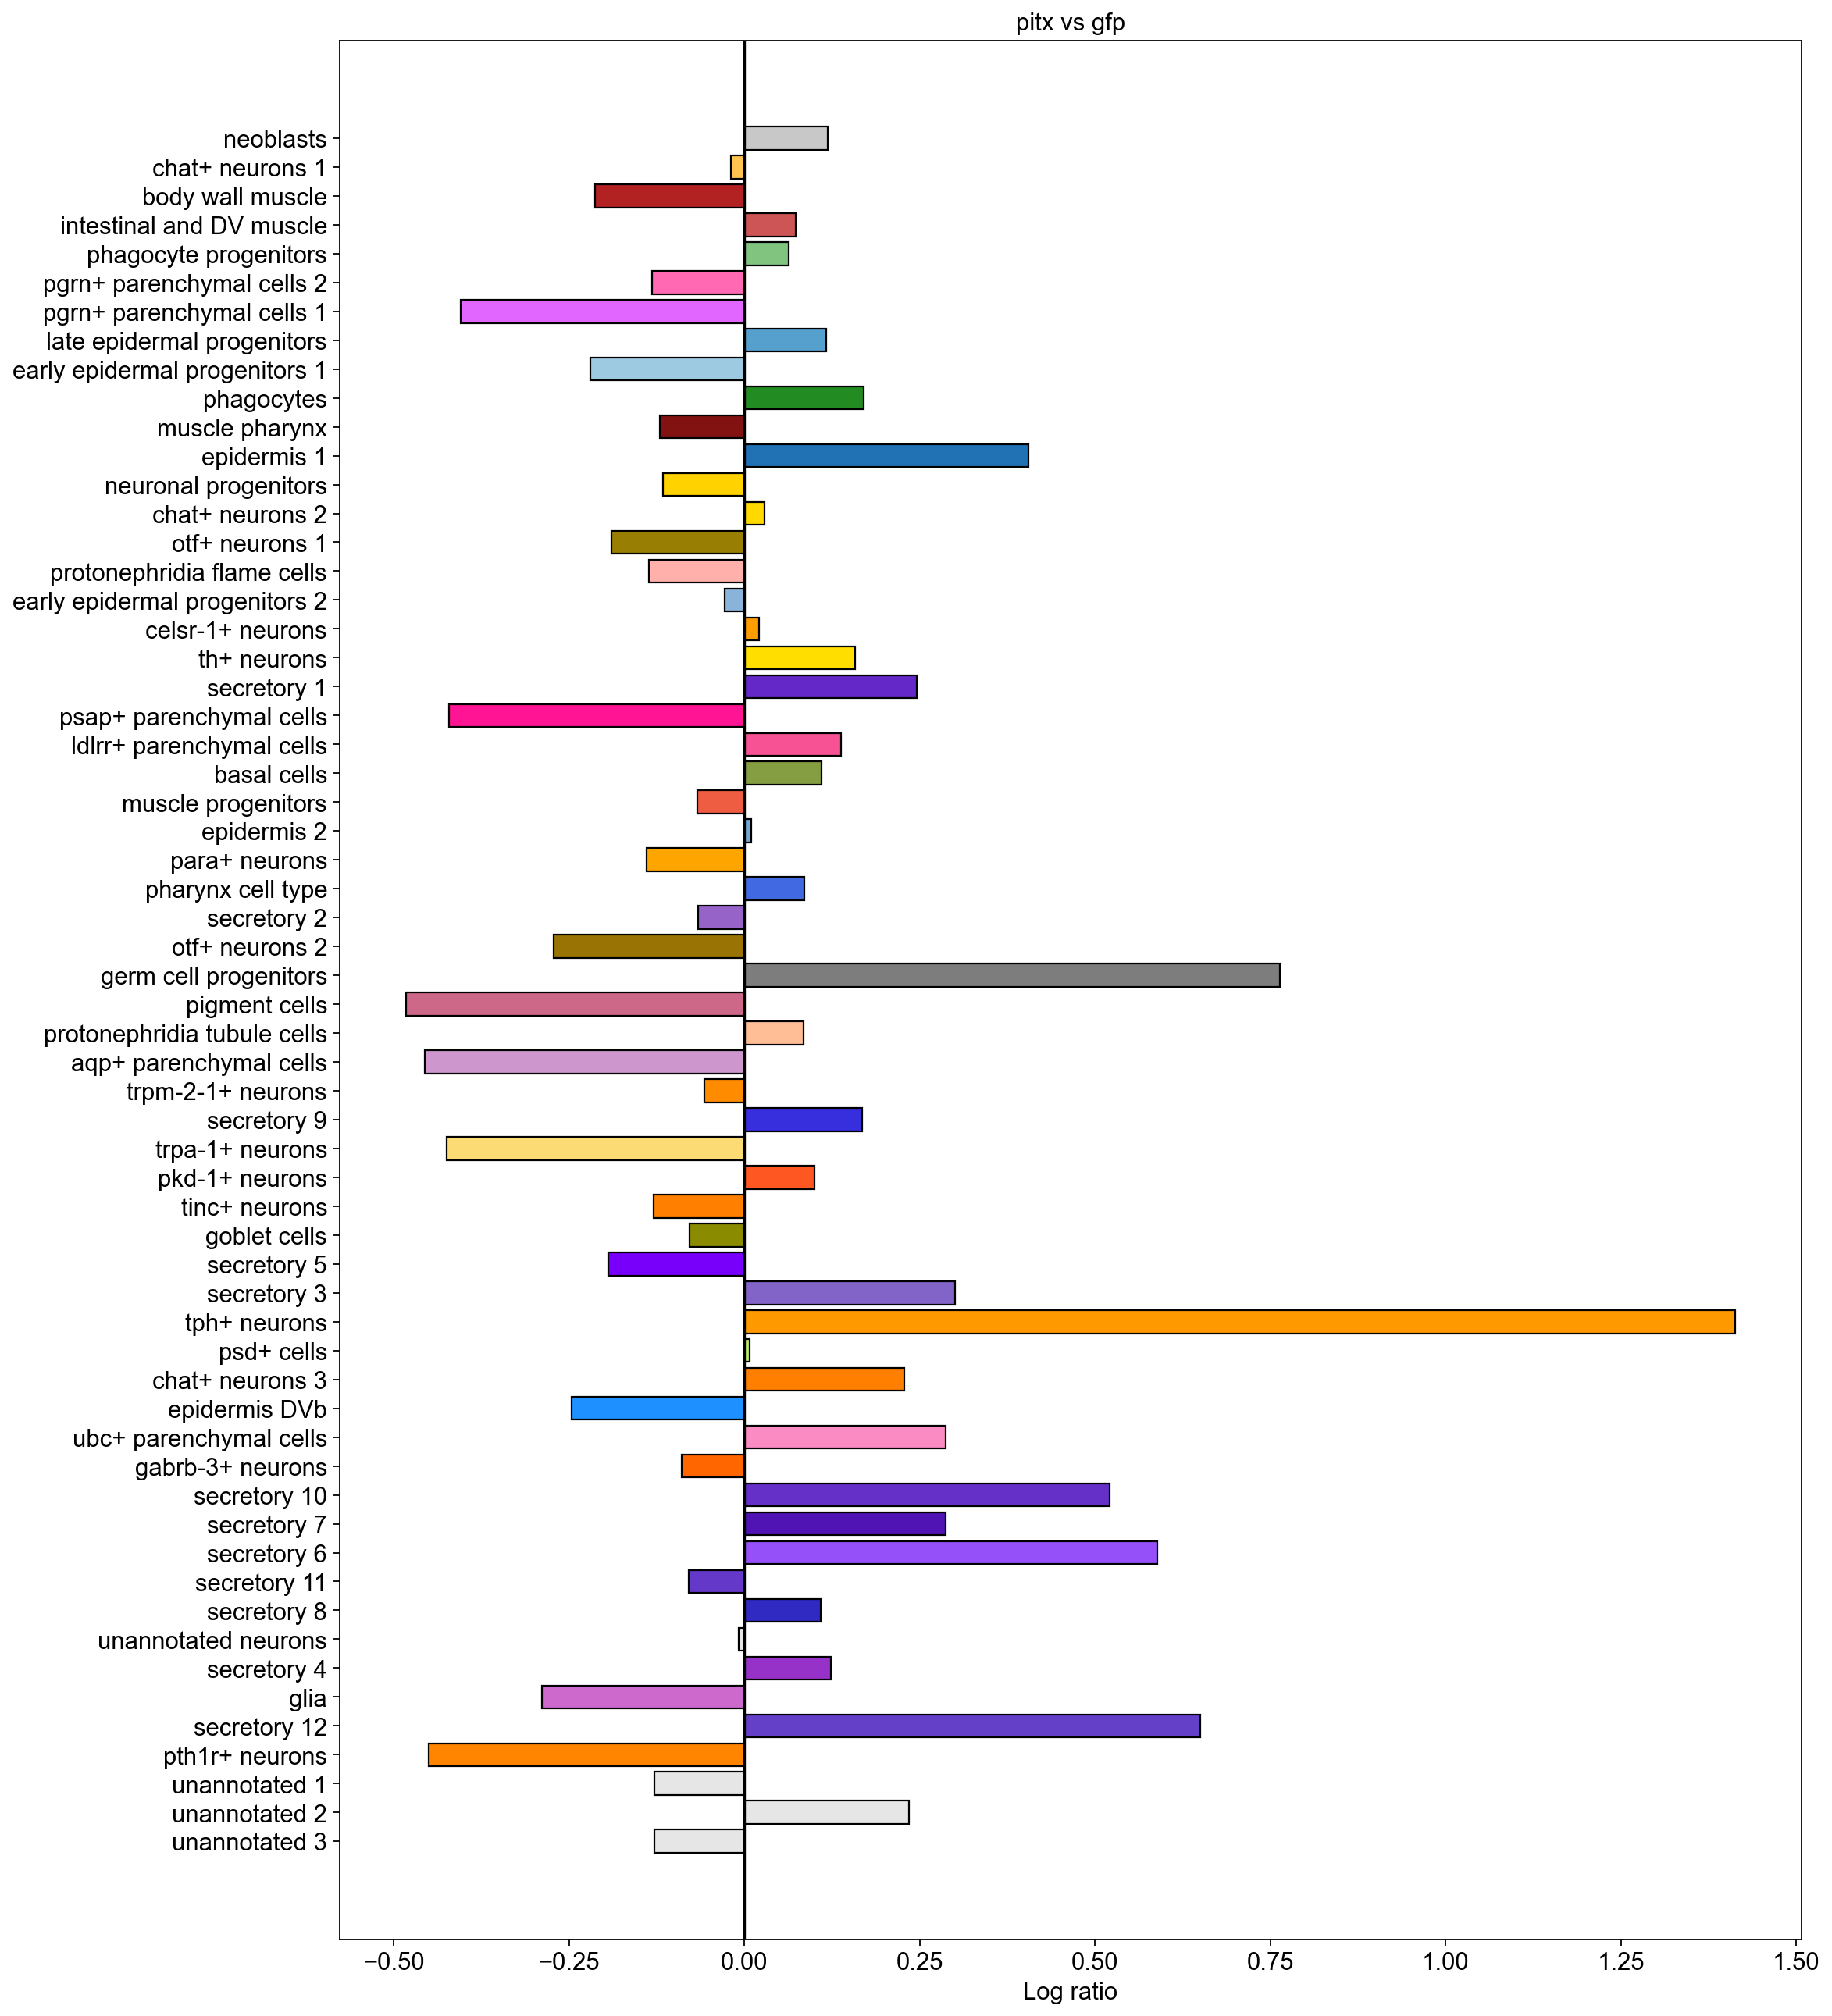

In [50]:
fig, axs = plt.subplots(figsize=(15, 20))

axs.barh(x_pos, Y_axis, edgecolor='black', color=adata_in_use.uns[clusteringlayer+'_colors'])
axs.grid(False)
axs.axvline(x=0, color='black', linestyle='-')
axs.set_title(test + ' vs ' + ctrl)
axs.set_xlabel('Log ratio')
axs.invert_yaxis()

fig.savefig('./outputs/fisher_test/barplot_adata2.pdf')

### Mosaic plot :

In [51]:
pd.set_option('use_inf_as_na', True)

Creating a **map** of clusters and **colours** (to use in plot palettes):

In [52]:
colour_mapping = {value: color for value, color in zip(adata_in_use.obs[clusteringlayer].unique().sort_values(), adata_in_use.uns[clusteringlayer+'_colors'])}

Defining plot **filters**:

In [53]:
# Filters for plot B:

not_in_filt1 = ft[(ft['odds']==0) & (ft['% diff'] > 0)]                                 # Selects values with 0 counts in one conditions
filt1 = adata_in_use[adata_in_use.obs[clusteringlayer].isin(list(not_in_filt1.index))]  # Filters adata to clusters in previous filter
value_counts1 = filt1.obs[clusteringlayer].value_counts()                               # Extracts counts for values in previous filters

In [54]:
# Filters for plot D:

not_in_filt2 = ft[(ft['odds']==0) & (ft['% diff'] < 0)]  
filt2 = adata_in_use[adata_in_use.obs[clusteringlayer].isin(list(not_in_filt2.index))]            
value_counts2 = filt2.obs[clusteringlayer].value_counts()                          

Plotting figure:

C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\Users\19125778\Anaconda3\lib\site-packages\pandas\core\internals\blocks.py:402: RuntimeWarning: invalid value encountered in log2
  result = func(self.values, **kwargs)
C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
C:\Users\19125778\Anaconda3\lib\site-packages\scanp

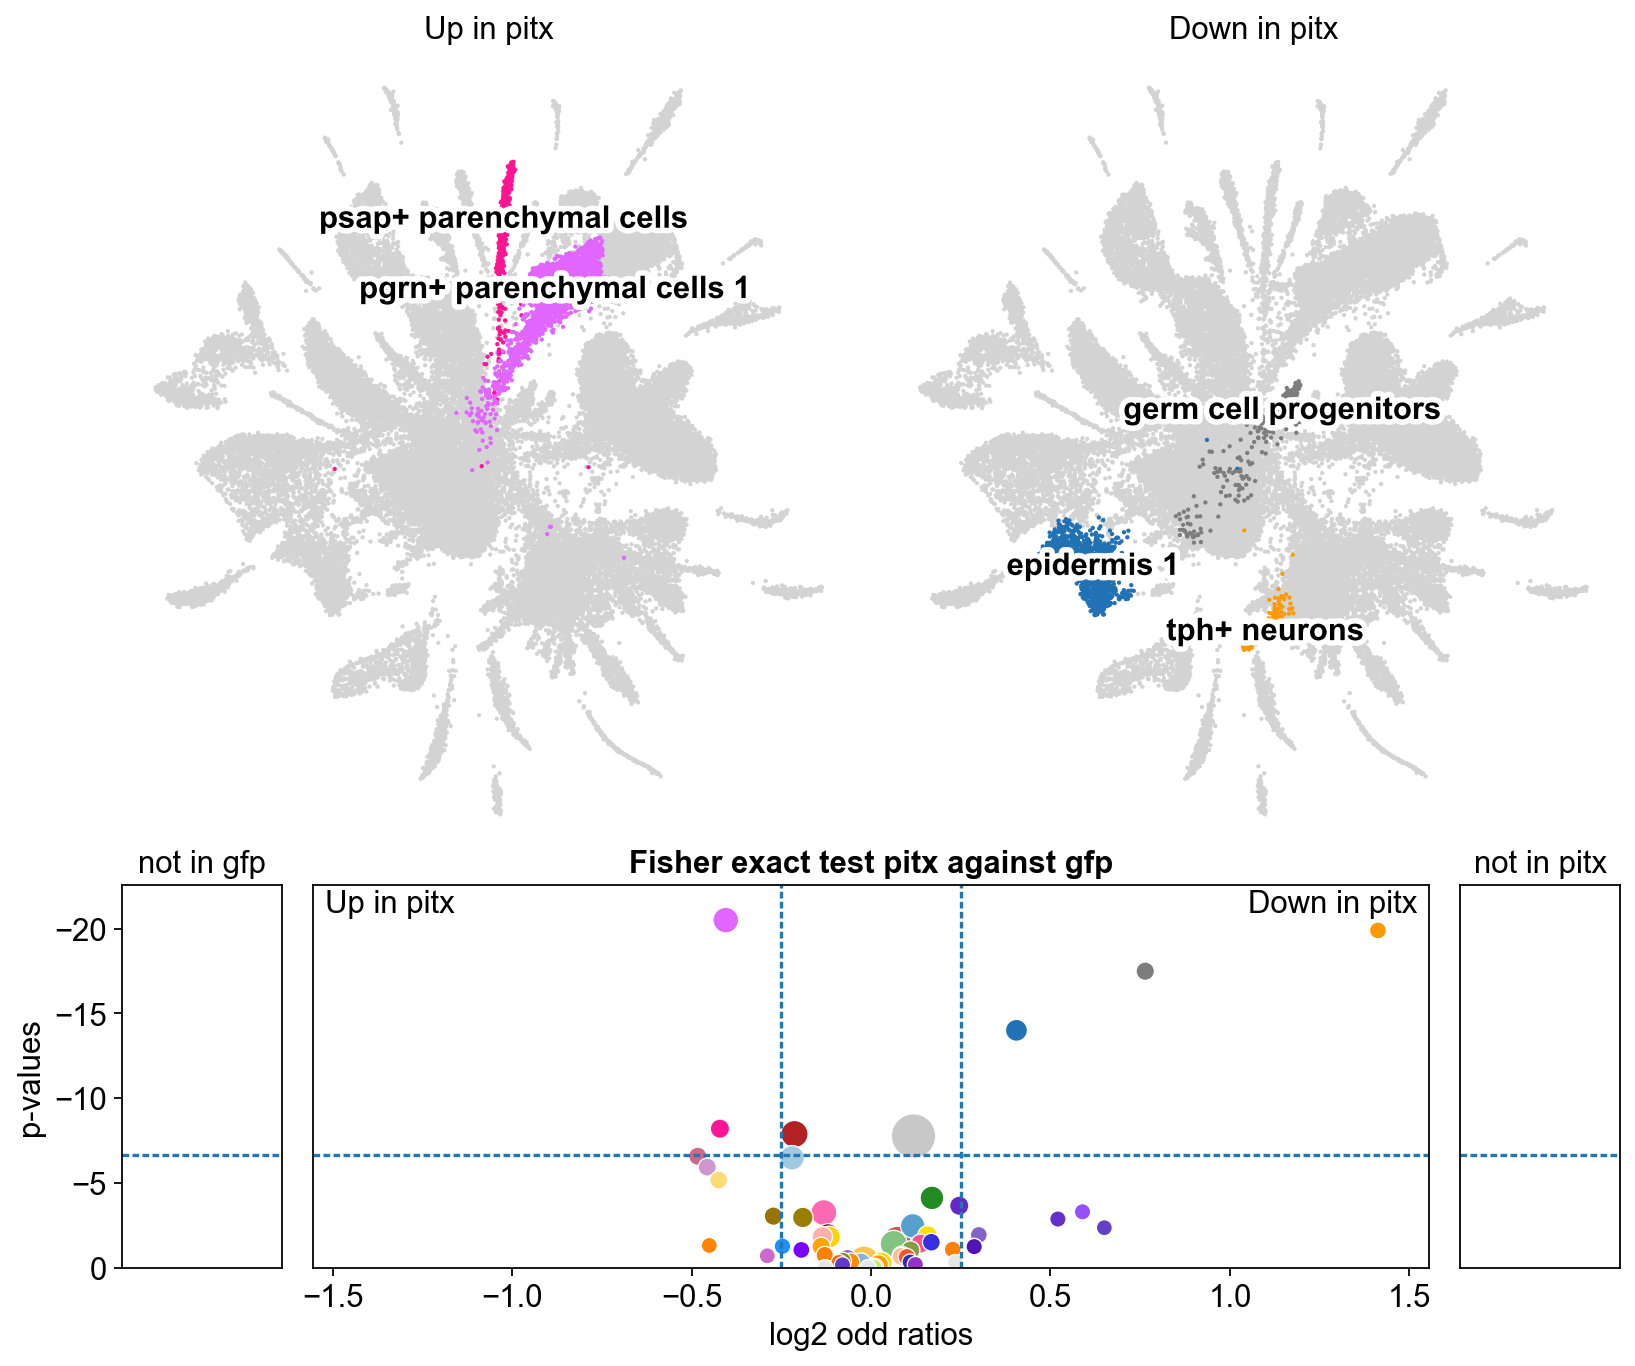

In [55]:
# FIGURE SIZE AND DISTRIBUTION:
   
    # AAAAEEE etc: Profiles the spatial distribution of plots labeled as A, B, C, D and E. 

fig = plt.figure(figsize=(12, 10))
axd = fig.subplot_mosaic(
    """
    AAAAEEEE
    AAAAEEEE
    AAAAEEEE
    AAAAEEEE
    BCCCCCCD
    BCCCCCCD
    """)

# DEFINITION OF AXES (axd):

max_y = abs(np.log2(ft['pvals'])).max() * 1.10          # Size limit of the y axis = maximum absolute value in column 'pvals' multiplied by a factor
max_x= abs(np.log2(ft['odds']).dropna()).max() * 1.10   # Size limit of the x axis = maximum absolute value in column 'odds' multiplied by a factor

# PLOT A: CLUSTERS UP

sc.pl.umap(adata_in_use, color=clusteringlayer, legend_loc='on data', legend_fontoutline = 5, title= 'Up in '+ test,
    size = 15, groups = up, na_in_legend=False, frameon=False, show = False, 
    ax = axd['A'])

# PLOT B: CLUSTERS NOT IN CTRL

sns.scatterplot(data = np.log2(not_in_filt1), x = 0, y = 'pvals',                       # Defines data and values in axes.
    size = value_counts1,                                                               # Cluster (dots) sizes are proportionate to their number of counts
    sizes = (50,400),                                                                   # Size of the smallest and biggest clusters (dots)
    hue = not_in_filt1.index,
    palette = [colour_mapping[value] for value in list(not_in_filt1.index.to_list())],
    legend = False,
    ax = axd['B'])
axd['B'].axhline(y=np.log2(sig), xmin=0, xmax=1, dashes = (2,1))
axd['B'].invert_yaxis()
axd['B'].set_title("not in " + ctrl)
axd['B'].set_ylim(0,-(max_y))
axd['B'].xaxis.set_visible(False)
axd['B'].set_ylabel('p-values')
axd['B'].grid(False)

# PLOT C: VOLCANO PLOT OF UP AND DOWN CLUSTERS

sns.scatterplot(data = np.log2(ft), x = 'odds', y = 'pvals',         # Defines data (log2) and values in axes.
    size = adata_in_use.obs[clusteringlayer].value_counts(),         # Cluster (dots) sizes are proportionate to their number of counts
    sizes=(50,400),                                                  # Size of the smallest and biggest clusters (dots)
    hue = ft.index,                                                  # Indicates what gets coloured (cluster names)
    palette = list(adata_in_use.uns[clusteringlayer+'_colors']),     # List of colours to use in the plot
    legend = False,                                                  # No legend in volcano plot
    ax = axd['C'])                                                   # Plot label
axd['C'].axhline(y=np.log2(sig), xmin=0, xmax=1, dashes = (2,1))     # Traces line in y-axis where y equals the logarithm of p-value (sig)
axd['C'].axvline(x= ot, ymin=0, ymax=1, dashes = (2,1))
axd['C'].axvline(x=-ot, ymin=0, ymax=1, dashes = (2,1))
axd['C'].invert_yaxis()
axd['C'].set_title('Fisher exact test ' + test + ' against ' + ctrl, weight="bold")
axd['C'].set_xlim(-(max_x), max_x)
axd['C'].set_ylim(0,-(max_y))
axd['C'].yaxis.set_visible(False)
axd['C'].set_xlabel('log2 odd ratios')
axd['C'].text(.01, .99, 'Up in '+ test, ha='left', va='top', transform=axd['C'].transAxes)
axd['C'].text(.99, .99, 'Down in '+ test, ha='right', va='top', transform=axd['C'].transAxes)
axd['C'].grid(False)

# PLOT D: CLUSTERS NOT IN TEST

sns.scatterplot(data = np.log2(not_in_filt2), x = 0, y = 'pvals', 
    size = value_counts2,
    sizes = (50, 400),
    hue = not_in_filt2.index,
    palette = [colour_mapping[value] for value in list(not_in_filt2.index.to_list())],
    legend = False,
    ax = axd['D'])
axd['D'].axhline(y=np.log2(sig), xmin=0, xmax=1, dashes = (2,1))
axd['D'].invert_yaxis()
axd['D'].set_title("not in "+ test)
axd['D'].set_ylim(0,-(max_y))
axd['D'].xaxis.set_visible(False)
axd['D'].yaxis.set_visible(False)
axd['D'].grid(False)

# PLOT E: CLUSTERS DOWN

sc.pl.umap(adata_in_use, color=clusteringlayer, legend_loc='on data', legend_fontoutline = 5, title= 'Down in '+ test,
        size = 15, groups = down, na_in_legend=False, frameon=False, show = False, 
        ax = axd['E'])

fig.savefig('./outputs/fisher_test/mosaic_adata2.pdf')